***ALZHEIMERS PREDICTION USING MACHINE LEARNING MODELS***

Alzheimer's disease is a neurodegenerative disorder that affects millions of people worldwide which leads to memory loss, cognitive decline, and changes in behavior. Early detection and accurate diagnosis are critical for managing the disease and improving the quality of life for patients. In this project, we aim to develop a predictive model to diagnose Alzheimer's disease using various machine learning algorithms.

The dataset used in this project contains information about patients,demographic details, medical history, lifestyle factors, and other relevant features. The target variable is the Alzheimer's diagnosis, which indicates whether a patient has been diagnosed with Alzheimer's disease or not. By analyzing these features, our goal is to create a model that can assist in early diagnosis, potentially leading to better treatment outcomes and management strategies for Alzheimer's patients.

**IMPORT STATEMENTS**

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [210]:
df=pd.read_csv("C:\\Users\\Harsha Krishnan\\Downloads\\alzheimers_prediction_dataset.csv")
df

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor,Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimers Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,Russia,60,Female,3,22.6,High,Former,Never,No,No,...,Average,High,Unemployed,Widowed,No,Medium,High,Medium,Rural,No
74279,UK,58,Male,18,30.6,Low,Never,Occasionally,Yes,No,...,Average,Medium,Unemployed,Single,No,Medium,High,High,Rural,No
74280,Spain,57,Female,13,28.2,Medium,Never,Regularly,No,No,...,Healthy,Low,Employed,Single,Yes,High,Low,Low,Rural,No
74281,Brazil,73,Female,7,29.0,Low,Never,Regularly,No,No,...,Healthy,Low,Employed,Widowed,No,Low,Low,High,Rural,No


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       74283 non-null  object 
 1   Age                           74283 non-null  int64  
 2   Gender                        74283 non-null  object 
 3   Education Level               74283 non-null  int64  
 4   BMI                           74283 non-null  float64
 5   Physical Activity Level       74283 non-null  object 
 6   Smoking Status                74283 non-null  object 
 7   Alcohol Consumption           74283 non-null  object 
 8   Diabetes                      74283 non-null  object 
 9   Hypertension                  74283 non-null  object 
 10  Cholesterol Level             74283 non-null  object 
 11  Family History of Alzheimers  74283 non-null  object 
 12  Cognitive Test Score          74283 non-null  int64  
 13  D

In [214]:
df.describe()

,Age,Education Level,BMI,Cognitive Test Score
count,74283.000000,74283.000000,74283.000000,74283.000000
mean,71.964703,9.487514,26.780639,64.654241
std,12.980748,5.757020,4.764679,20.153247
min,50.000000,0.000000,18.500000,30.000000
25%,61.000000,4.000000,22.700000,47.000000
50%,72.000000,9.000000,26.800000,65.000000
75%,83.000000,14.000000,30.900000,82.000000
max,94.000000,19.000000,35.000000,99.000000


In [216]:
df.nunique()

Country                          20
Age                              45
Gender                            2
Education Level                  20
BMI                             166
Physical Activity Level           3
Smoking Status                    3
Alcohol Consumption               3
Diabetes                          2
Hypertension                      2
Cholesterol Level                 2
Family History of Alzheimers      2
Cognitive Test Score             70
Depression Level                  3
Sleep Quality                     3
Dietary Habits                    3
Air Pollution Exposure            3
Employment Status                 3
Marital Status                    3
Genetic Risk Factor               2
Social Engagement Level           3
Income Level                      3
Stress Levels                     3
Urban vs Rural Living             2
Alzheimers Diagnosis              2
dtype: int64

In [218]:
df.isnull().sum()

Country                         0
Age                             0
Gender                          0
Education Level                 0
BMI                             0
Physical Activity Level         0
Smoking Status                  0
Alcohol Consumption             0
Diabetes                        0
Hypertension                    0
Cholesterol Level               0
Family History of Alzheimers    0
Cognitive Test Score            0
Depression Level                0
Sleep Quality                   0
Dietary Habits                  0
Air Pollution Exposure          0
Employment Status               0
Marital Status                  0
Genetic Risk Factor             0
Social Engagement Level         0
Income Level                    0
Stress Levels                   0
Urban vs Rural Living           0
Alzheimers Diagnosis            0
dtype: int64

**DATA VISUALISATION**

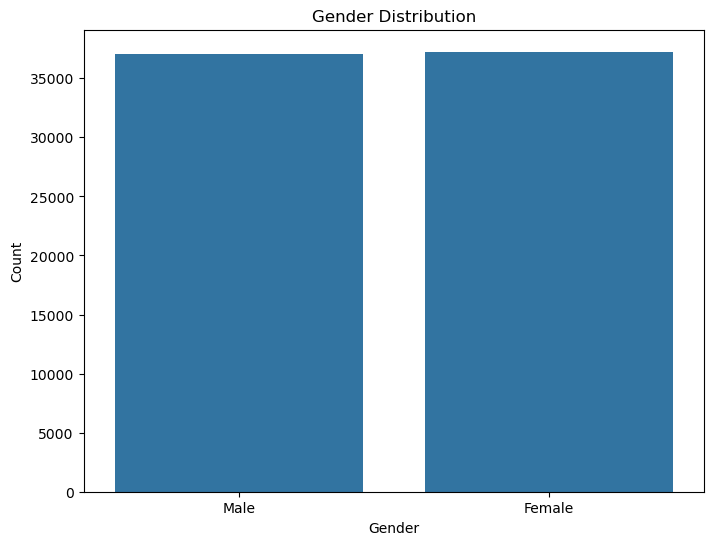

In [221]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

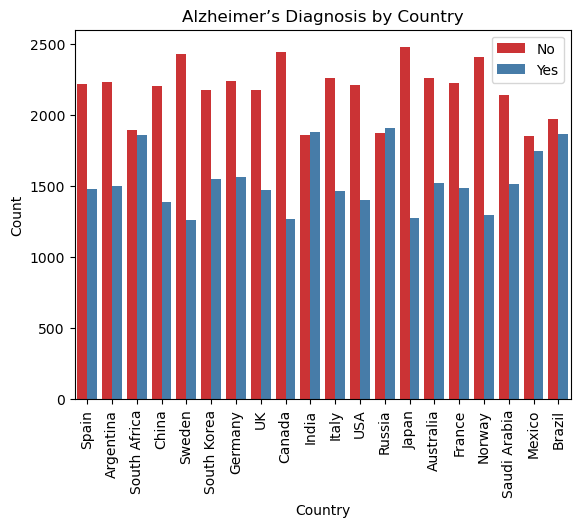

In [222]:
sns.countplot(x='Country', hue='Alzheimers Diagnosis', data=df, palette='Set1')
plt.title('Alzheimer’s Diagnosis by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(loc='upper right')
plt.show()

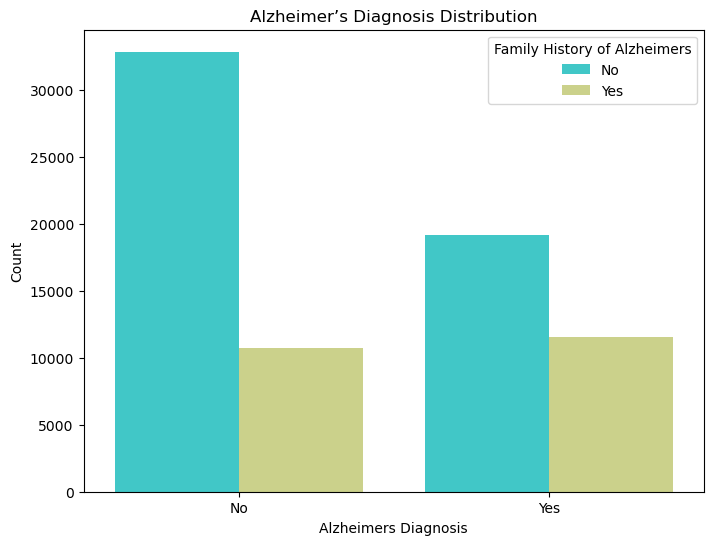

In [224]:
plt.figure(figsize=(8, 6))
sns.countplot(x="Alzheimers Diagnosis", data=df,hue="Family History of Alzheimers",palette="rainbow")
plt.title('Alzheimer’s Diagnosis Distribution')
plt.xlabel('Alzheimers Diagnosis')
plt.ylabel('Count')
plt.show()

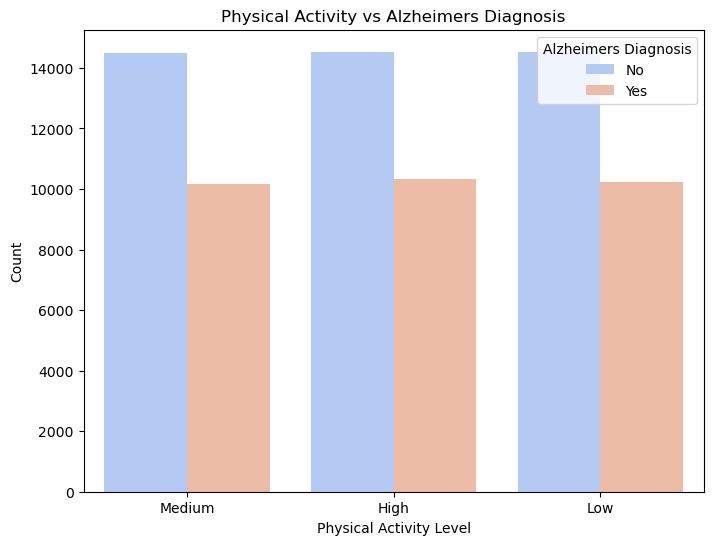

In [225]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Physical Activity Level', hue='Alzheimers Diagnosis', data=df, palette='coolwarm')
plt.title('Physical Activity vs Alzheimers Diagnosis')
plt.xlabel('Physical Activity Level')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Frequency')

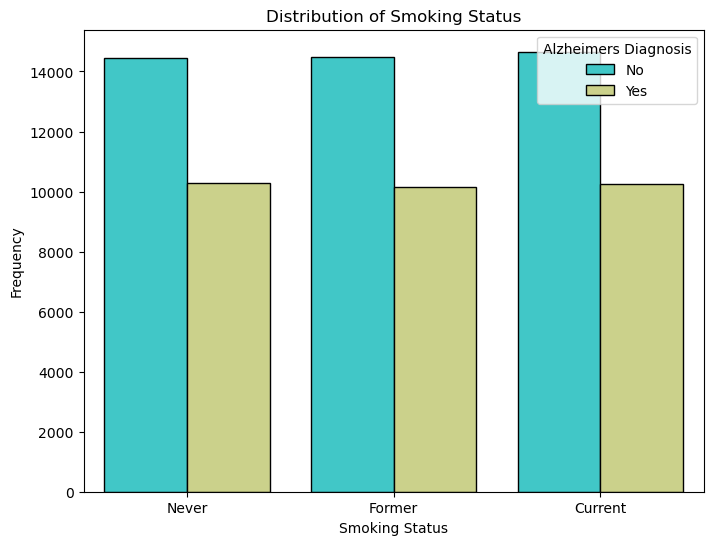

In [228]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x='Smoking Status', palette='rainbow', edgecolor='black',hue="Alzheimers Diagnosis")
plt.title('Distribution of Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')

Text(0, 0.5, 'Count')

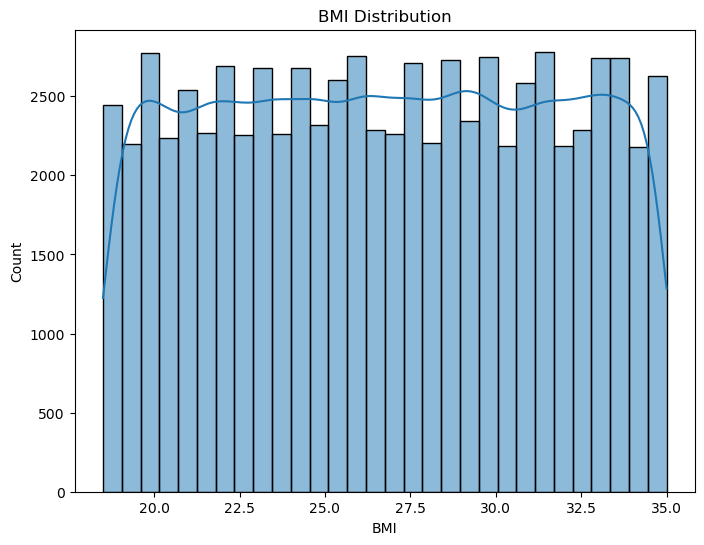

In [230]:
fig,ax=plt.subplots(figsize=(8,6))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

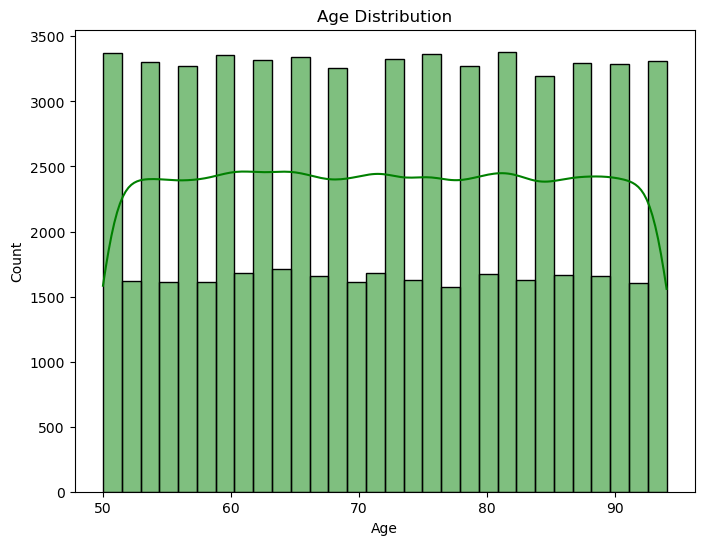

In [231]:
fig,ax=plt.subplots(figsize=(8,6))
sns.histplot(df['Age'], bins=30, kde=True,color='green')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

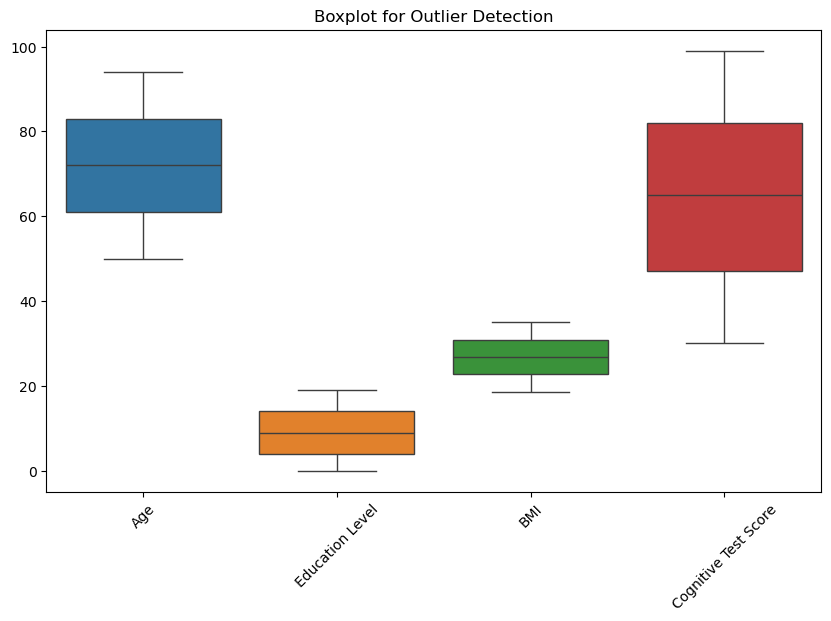

In [235]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

**CORRELATION ANALYSIS**

In [238]:
numeric_df=df.select_dtypes(include=["int64","float64"])

In [240]:
cor=numeric_df.corr()
cor

,Age,Education Level,BMI,Cognitive Test Score
Age,1.000000,0.006511,-0.000135,0.000049
Education Level,0.006511,1.000000,0.005444,-0.002519
BMI,-0.000135,0.005444,1.000000,0.005538
Cognitive Test Score,0.000049,-0.002519,0.005538,1.000000


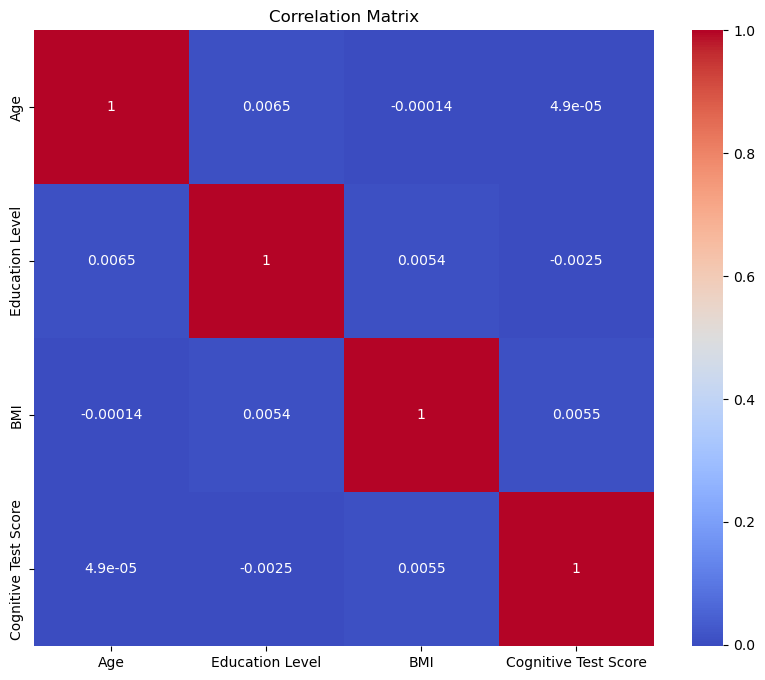

In [242]:
plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**ENCODING THE DATA**

In [245]:
df['Alzheimers Diagnosis'] = df['Alzheimers Diagnosis'].map({'No': 0, 'Yes': 1})
df_encoded=pd.get_dummies(df,columns=['Gender', 'Education Level', 'Country','Physical Activity Level','Smoking Status', 'Alcohol Consumption','Diabetes', 'Hypertension', 'Cholesterol Level', 'Family History of Alzheimers', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 'Air Pollution Exposure','Genetic Risk Factor ', 'Social Engagement Level', 'Marital Status', 'Employment Status', 'Urban vs Rural Living', 'Income Level', 'Stress Levels'],drop_first=True,dtype=int)

In [247]:
df_encoded.head(20)

,Age,BMI,Cognitive Test Score,Alzheimers Diagnosis,Gender_Male,Education Level_1,Education Level_2,Education Level_3,Education Level_4,Education Level_5,...,Social Engagement Level_Medium,Marital Status_Single,Marital Status_Widowed,Employment Status_Retired,Employment Status_Unemployed,Urban vs Rural Living_Urban,Income Level_Low,Income Level_Medium,Stress Levels_Low,Stress Levels_Medium
0,90,33.0,90,0,1,1,0,0,0,0,...,0,1,0,1,0,1,0,1,0,0
1,72,29.9,65,0,1,0,0,0,0,0,...,0,0,1,0,1,1,1,0,0,0
2,86,22.9,43,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,53,31.2,81,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,1,1,0
4,58,30.0,49,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
5,55,34.0,36,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
6,91,24.1,68,0,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,0,1
7,67,23.6,49,1,0,0,0,0,0,0,...,0,0,1,0,1,1,0,1,0,0
8,84,22.0,55,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,1,0
9,72,32.4,50,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1


In [249]:
num_cols = ['Age', 'BMI', 'Cognitive Test Score']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [251]:
X = df_encoded.drop('Alzheimers Diagnosis', axis=1)
y = df_encoded['Alzheimers Diagnosis']

In [253]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**LOGISTIC REGRESSION**

In [286]:
logistic_model=LogisticRegression()

In [288]:
logistic_model.fit(X_train,y_train)

LogisticRegression()

In [290]:
y_pred_log=logistic_model.predict(X_test)
y_pred_log

array([1, 1, 0, ..., 1, 0, 0], dtype=int64)

In [292]:
print("Accuracy of logistic regression model:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
confusion_matrix(y_test, y_pred_log)

Accuracy of logistic regression model: 0.7176415157838056
              precision    recall  f1-score   support

           0       0.74      0.79      0.77      8714
           1       0.68      0.61      0.64      6143

    accuracy                           0.72     14857
   macro avg       0.71      0.70      0.70     14857
weighted avg       0.71      0.72      0.71     14857



array([[6927, 1787],
       [2408, 3735]], dtype=int64)

**RANDOM FOREST**

In [298]:
forest_model=RandomForestClassifier()

In [300]:
n_estimators = [100,200]
max_features = [2, 3]
max_depth=[5,10,None]

In [302]:
param_grids = {'n_estimators':n_estimators,'max_features':max_features,"max_depth":max_depth}

In [306]:
grid=GridSearchCV(forest_model,param_grids,verbose=2,cv=3)

In [308]:
grid.fit(X_train,y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ......max_depth=5, max_features=2, n_estimators=100; total time=   1.7s
[CV] END ......max_depth=5, max_features=2, n_estimators=100; total time=   1.4s
[CV] END ......max_depth=5, max_features=2, n_estimators=100; total time=   1.5s
[CV] END ......max_depth=5, max_features=2, n_estimators=200; total time=   3.0s
[CV] END ......max_depth=5, max_features=2, n_estimators=200; total time=   3.0s
[CV] END ......max_depth=5, max_features=2, n_estimators=200; total time=   3.0s
[CV] END ......max_depth=5, max_features=3, n_estimators=100; total time=   1.7s
[CV] END ......max_depth=5, max_features=3, n_estimators=100; total time=   1.6s
[CV] END ......max_depth=5, max_features=3, n_estimators=100; total time=   1.6s
[CV] END ......max_depth=5, max_features=3, n_estimators=200; total time=   3.3s
[CV] END ......max_depth=5, max_features=3, n_estimators=200; total time=   3.4s
[CV] END ......max_depth=5, max_features=3, n_es

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None], 'max_features': [2, 3],
                         'n_estimators': [100, 200]},
             verbose=2)

In [310]:
best_forest_parameter=grid.best_estimator_
best_forest_parameter

RandomForestClassifier(max_features=3, n_estimators=200)

In [312]:
y_pred_forest=best_forest_parameter.predict(X_test)
y_pred_forest

array([0, 1, 0, ..., 0, 0, 1], dtype=int64)

In [314]:
print("Accuracy of random forest model:", accuracy_score(y_test, y_pred_forest))
print(classification_report(y_test, y_pred_forest))
confusion_matrix(y_test, y_pred_forest)

Accuracy of random forest model: 0.7162280406542371
              precision    recall  f1-score   support

           0       0.72      0.84      0.78      8714
           1       0.70      0.54      0.61      6143

    accuracy                           0.72     14857
   macro avg       0.71      0.69      0.69     14857
weighted avg       0.71      0.72      0.71     14857



array([[7303, 1411],
       [2805, 3338]], dtype=int64)

**DECISION TREE CLASSIFIER**

In [316]:
tree_model=DecisionTreeClassifier(random_state=42)

In [318]:
criterion=["gini","entropy"]
min_samples_split=[2,7,10]
max_depth=[3,7,None]

In [320]:
params_grid={"criterion":criterion,"min_samples_split":min_samples_split,"max_depth":max_depth}

In [322]:
grid=GridSearchCV(tree_model,params_grid,verbose=2,cv=3)

In [324]:
grid.fit(X_train,y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.2s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=7; total time=   0.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=7; total time=   0.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=7; total time=   0.1s
[CV] END ..criterion=gini, max_depth=3, min_samples_split=10; total time=   0.1s
[CV] END ..criterion=gini, max_depth=3, min_samples_split=10; total time=   0.1s
[CV] END ..criterion=gini, max_depth=3, min_samples_split=10; total time=   0.1s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.4s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.3s
[CV] END ...criterion=gini, max_depth=7, min_sam

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 7, None],
                         'min_samples_split': [2, 7, 10]},
             verbose=2)

In [326]:
best_tree_parameter=grid.best_estimator_

In [328]:
grid.best_estimator_

DecisionTreeClassifier(max_depth=3, random_state=42)

In [330]:
y_pred_tree=best_tree_parameter.predict(X_test)

In [332]:
print("Accuracy of decision tree model:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
confusion_matrix(y_test, y_pred_tree)

Accuracy of decision tree model: 0.7296897085548899
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      8714
           1       0.65      0.74      0.69      6143

    accuracy                           0.73     14857
   macro avg       0.72      0.73      0.73     14857
weighted avg       0.74      0.73      0.73     14857



array([[6318, 2396],
       [1620, 4523]], dtype=int64)

**K-Nearest Neighbor**

In [335]:
knn_model=KNeighborsClassifier(n_neighbors=7)

In [337]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [339]:
y_pred_knn=knn_model.predict(X_test)

In [340]:
print("Accuracy of KNN model:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
confusion_matrix(y_test, y_pred_knn)

Accuracy of KNN model: 0.6711987615265531
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      8714
           1       0.62      0.52      0.57      6143

    accuracy                           0.67     14857
   macro avg       0.66      0.65      0.65     14857
weighted avg       0.67      0.67      0.67     14857



array([[6784, 1930],
       [2955, 3188]], dtype=int64)

**SUPPORT VECTOR MACHINE**

In [344]:
svm_model=SVC(kernel="linear",random_state=42)

In [346]:
svm_model.fit(X_train,y_train)

SVC(kernel='linear', random_state=42)

In [348]:
y_pred_svm=svm_model.predict(X_test)

In [349]:
print("Accuracy of SVM model:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
confusion_matrix(y_test, y_pred_svm)

Accuracy of SVM model: 0.7201992326849297
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      8714
           1       0.67      0.65      0.66      6143

    accuracy                           0.72     14857
   macro avg       0.71      0.71      0.71     14857
weighted avg       0.72      0.72      0.72     14857



array([[6737, 1977],
       [2180, 3963]], dtype=int64)

*Hyperparameter tuning using sample for SVM*

In [259]:
df_encoded_sampled = df_encoded.sample(frac=0.2, random_state=42)
X_sample = df_encoded_sampled.drop(columns=['Alzheimers Diagnosis'])
y_sample = df_encoded_sampled['Alzheimers Diagnosis']
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

In [261]:
c=[0.1, 1, 10]
gamma= ["scale","auto"]
kernel=["linear","rbf"]

In [263]:
param_grids={"C":c,"kernel":kernel,"gamma":gamma}

In [265]:
grid=GridSearchCV(svm_model,param_grids,verbose=2)

In [267]:
grid.fit(X_train_sample,y_train_sample)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  14.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  14.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  14.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  13.7s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  13.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.9s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  12.8s
[CV] END ...................C=0.1, gamma=auto, k

GridSearchCV(estimator=SVC(kernel='linear', random_state=42),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             verbose=2)

In [269]:
best_svc_parameters=grid.best_estimator_
best_svc_parameters

SVC(C=0.1, random_state=42)

In [271]:
y_pred_svc=best_svc_parameters.predict(X_test_sample)

In [273]:
print("Accuracy of hyperparameter tuned SVM model:", accuracy_score(y_test_sample, y_pred_svc))
print(classification_report(y_test_sample, y_pred_svc))
confusion_matrix(y_test_sample, y_pred_svc)

Accuracy of hyperparameter tuned SVM model: 0.7234185733512786
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1736
           1       0.68      0.63      0.66      1236

    accuracy                           0.72      2972
   macro avg       0.72      0.71      0.71      2972
weighted avg       0.72      0.72      0.72      2972



array([[1369,  367],
       [ 455,  781]], dtype=int64)

**CONCLUSION**

In [352]:
models = ['Logistic Regression','Random Forest', 'Decision Tree','KNN', 'Support Vector']
accuracies = [accuracy_score(y_test, y_pred_log),accuracy_score(y_test, y_pred_forest),accuracy_score(y_test, y_pred_tree),accuracy_score(y_test, y_pred_knn),accuracy_score(y_test, y_pred_svm)]

In [354]:
df_results = pd.DataFrame({'Model': models, 'Accuracy': accuracies})
df_results

,Model,Accuracy
0,Logistic Regression,0.717642
1,Random Forest,0.716228
2,Decision Tree,0.729690
3,KNN,0.671199
4,Support Vector,0.720199


**Based on the accuracy comparison of various models, the decision tree model achieves an accuracy of approximately 73%, making it the best fit for prediction.**